In [1]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import math
import gc
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
df = pd.read_csv('Yemen_Rainfall_1982_2025.csv')
df

,Unnamed: 0,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version,month,dekad,year
0,454320,1982-01-01,2,32878,0,24.0,1.000000,1.043055,4.000000,3.880556,9.833333,14.137500,99.287520,101.34500,77.509250,final,1,1,1982
1,478770,1982-01-01,2,32893,1,19.0,1.157895,1.049123,4.157895,4.145614,9.263158,13.300000,101.798140,100.13426,77.940760,final,1,1,1982
2,455950,1982-01-01,2,32879,2,10.0,1.000000,1.023333,4.000000,4.253334,9.400000,12.836667,99.612610,97.26224,80.732574,final,1,1,1982
3,457580,1982-01-01,2,32880,3,9.0,1.000000,1.003704,4.000000,4.166666,9.888889,13.162963,99.938310,98.18182,81.973900,final,1,1,1982
4,464100,1982-01-01,2,32884,4,6.0,1.000000,1.055556,4.000000,4.094444,10.000000,13.688889,99.082570,98.96152,80.261600,final,1,1,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503707,277333,2025-12-21,2,145040,313,7.0,2.000000,1.652381,4.285714,4.523809,12.142858,17.409523,105.225480,97.50000,76.498085,final,12,21,2025
503708,273655,2025-12-21,2,145039,314,9.0,2.000000,1.600000,4.000000,4.322222,12.444444,17.692593,106.060616,96.54351,76.872850,final,12,21,2025
503709,292463,2025-12-21,2,999528,315,10.0,1.800000,1.570000,4.600000,4.146667,17.800000,21.576668,103.500770,104.95627,85.789530,final,12,21,2025
503710,228307,2025-12-21,2,145016,316,88.0,14.522727,14.787121,34.545456,41.764393,58.613636,74.689390,98.663810,84.56318,79.826980,final,12,21,2025


In [4]:
df = df.drop(['rfq','r1q','r3q','rfh_avg','r1h_avg','r3h_avg','n_pixels','version','Unnamed: 0','adm_id', 'adm_level'], axis=1)
df = df.sort_values(by=['PCODE', 'year', 'month', 'dekad']).reset_index(drop=True)
df

,date,PCODE,rfh,r1h,r3h,month,dekad,year
0,1982-01-01,0,1.000000,4.000000,9.833333,1,1,1982
1,1982-01-11,0,3.000000,6.000000,12.000000,1,11,1982
2,1982-01-21,0,1.000000,5.000000,12.000000,1,21,1982
3,1982-02-01,0,1.000000,5.000000,12.000000,2,1,1982
4,1982-02-11,0,3.583333,5.583333,14.583333,2,11,1982
...,...,...,...,...,...,...,...,...
503707,2025-11-11,317,5.289473,10.289474,12.657895,11,11,2025
503708,2025-11-21,317,6.394737,15.473684,18.789474,11,21,2025
503709,2025-12-01,317,7.710527,19.394737,26.184212,12,1,2025
503710,2025-12-11,317,11.842105,25.947369,37.710526,12,11,2025


In [5]:
# Lag features
for lag in [1, 2, 3, 6, 12]:
    df[f'rfh_lag_{lag}'] = df.groupby('PCODE')['rfh'].shift(lag)
df = df.dropna().reset_index(drop=True)

# Encode PCODE
df['PCODE'] = df['PCODE'].astype('category').cat.codes
NUM_PCODES  = df['PCODE'].nunique()

# Cyclic time features
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dekad_sin'] = np.sin(2 * np.pi * df['dekad'] / 3)
df['dekad_cos'] = np.cos(2 * np.pi * df['dekad'] / 3)

print(f'df: {df.shape}, PCODEs: {NUM_PCODES}')
df.head()

df: (499896, 17), PCODEs: 318


,date,PCODE,rfh,r1h,r3h,month,dekad,year,rfh_lag_1,rfh_lag_2,rfh_lag_3,rfh_lag_6,rfh_lag_12,month_sin,month_cos,dekad_sin,dekad_cos
0,1982-05-01,0,11.666667,19.708334,37.625000,5,1,1982,3.333333,4.708334,4.041666,1.000000,1.000000,5.000000e-01,-0.866025,8.660254e-01,-0.5
1,1982-05-11,0,14.416667,29.416668,48.458336,5,11,1982,11.666667,3.333333,4.708334,0.291667,3.000000,5.000000e-01,-0.866025,-8.660254e-01,-0.5
2,1982-05-21,0,7.125000,33.208336,54.583336,5,21,1982,14.416667,11.666667,3.333333,8.000000,1.000000,5.000000e-01,-0.866025,-1.714506e-15,1.0
3,1982-06-01,0,1.333333,22.875002,54.916668,6,1,1982,7.125000,14.416667,11.666667,4.041666,1.000000,1.224647e-16,-1.000000,8.660254e-01,-0.5
4,1982-06-11,0,0.000000,8.458333,54.625000,6,11,1982,1.333333,7.125000,14.416667,4.708334,3.583333,1.224647e-16,-1.000000,-8.660254e-01,-0.5


In [6]:
train_df = df[df['year'] <= 2015]
val_df = df[(df['year'] > 2015) & (df['year'] <= 2020)]
test_df = df[df['year'] > 2020]

print("train:",(train_df.shape))
print("val:",(val_df.shape))
print("test:",(test_df.shape))

train: (385416, 17)
val: (57240, 17)
test: (57240, 17)


In [7]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

In [8]:
transform_cols = [
    'rfh', 'r1h', 'r3h',
    'rfh_lag_1', 'rfh_lag_2','rfh_lag_3', 'rfh_lag_6','rfh_lag_12'
]
# Apply Yeo–Johnson
pt = PowerTransformer(method='yeo-johnson')

train_df[transform_cols] = pt.fit_transform(train_df[transform_cols])
val_df[transform_cols] = pt.transform(val_df[transform_cols])
test_df[transform_cols] = pt.transform(test_df[transform_cols])

# Apply RobustScaler
scaler = RobustScaler()

train_df[transform_cols] = scaler.fit_transform(train_df[transform_cols])
val_df[transform_cols] = scaler.transform(val_df[transform_cols])
test_df[transform_cols] = scaler.transform(test_df[transform_cols])

In [9]:
FEATURES = [
    'rfh','r1h','r3h',
    'rfh_lag_1','rfh_lag_2','rfh_lag_3','rfh_lag_6','rfh_lag_12',
    'month_sin','month_cos','dekad_sin','dekad_cos',
    'month','dekad',
]
TARGET    = 'rfh'
SEQ_LEN   = 24
NUM_FEATS = len(FEATURES)
print(f'Features: {NUM_FEATS} , Sequence length: {SEQ_LEN}')

Features: 14 , Sequence length: 24


In [10]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values

X_val = val_df[FEATURES].values
y_val = val_df[TARGET].values

X_test = test_df[FEATURES].values
y_test = test_df[TARGET].values

X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_val = X_val.astype('float32')
y_val = y_val.astype('float32')
X_test = X_test.astype('float32')
y_test = y_test.astype('float32')

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val)
y_val = torch.tensor(y_val)
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

In [11]:
def create_sequences_per_pcode(df, features, target, seq_len=24):
    X_list, y_list, pcode_list = [], [], []

    for pcode, group in df.groupby('PCODE'):
        group = group.sort_values(['year','month','dekad'])

        X = group[features].values
        y = group[target].values

        for i in range(len(group) - seq_len):
            X_list.append(X[i:i+seq_len])
            y_list.append(y[i+seq_len])
            pcode_list.append(pcode)

    return (
        torch.tensor(X_list, dtype=torch.float32),
        torch.tensor(y_list, dtype=torch.float32),
        torch.tensor(pcode_list, dtype=torch.long)
    )

In [12]:
X_train, y_train, p_train = create_sequences_per_pcode(train_df, FEATURES, TARGET, seq_len=24)
X_val, y_val, p_val       = create_sequences_per_pcode(val_df, FEATURES, TARGET, seq_len=24)
X_test, y_test, p_test    = create_sequences_per_pcode(test_df, FEATURES, TARGET, seq_len=24)

/tmp/ipykernel_4055/3299349123.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(X_list, dtype=torch.float32),


In [13]:
train_ds = TensorDataset(X_train, y_train, p_train)
val_ds   = TensorDataset(X_val, y_val, p_val)
test_ds  = TensorDataset(X_test, y_test, p_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, pin_memory=True)

In [14]:
class iTransformer(nn.Module):
    def __init__(self, num_features, seq_len, num_pcodes, d_model=128, n_heads=4, num_layers=3, d_ff=256, dropout=0.1, pcode_embed_dim=16):
        super().__init__()

        # 1. PCODE embedding
        self.pcode_emb = nn.Embedding(num_pcodes, pcode_embed_dim)
        # 2. Inverted embedding (Time - Representation)
        self.value_embedding = nn.Linear(seq_len, d_model)
        # 3. Feature (token) embedding
        self.feature_embedding = nn.Parameter(torch.randn(1, num_features, d_model))
        # 4. Combine dim
        self.total_dim = d_model + pcode_embed_dim

        # 5. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.total_dim,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # 6. LayerNorm
        self.norm = nn.LayerNorm(self.total_dim)

        # 7. Prediction head
        self.head = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, pcode):
        # x: (B, T, F)

        B, T, F = x.shape

        # 1. Invert → (B, F, T)
        x = x.permute(0, 2, 1)

        # 2. Project time → representation
        x = self.value_embedding(x)  # (B, F, d_model)

        # 3. Add feature embedding (VERY IMPORTANT - paper detail)
        x = x + self.feature_embedding

        # 4. PCODE embedding
        p_emb = self.pcode_emb(pcode)  # (B, E)
        p_emb = p_emb.unsqueeze(1).expand(-1, F, -1)

        # 5. Concatenate
        x = torch.cat([x, p_emb], dim=-1)

        # 6. Normalize
        x = self.norm(x)

        # 7. Transformer (attention across FEATURES)
        x = self.encoder(x)

        # 8. Aggregation (mean over features)
        x = x.mean(dim=1)

        # 9. Prediction
        out = self.head(x)

        return out.squeeze()

In [15]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X, y, p in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        p = p.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = model(X, p)
        loss = criterion(out, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0


    with torch.no_grad():
        for X, y, p in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            p = p.to(device, non_blocking=True)

            out = model(X, p)
            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0


    with torch.no_grad():
        for X, y, p in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            p = p.to(device, non_blocking=True)

            out = model(X, p)
            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [16]:
def objective(trial):

    # Search space
    d_model = trial.suggest_categorical("d_model", [64, 128, 256])
    n_heads = trial.suggest_categorical("n_heads", [2, 4, 8])
    num_layers = trial.suggest_int("num_layers", 2, 4)
    d_ff = trial.suggest_categorical("d_ff", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    pcode_embed_dim = trial.suggest_categorical("pcode_embed_dim", [8, 16, 32])
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    total_dim = d_model + pcode_embed_dim
    if total_dim % n_heads != 0:
        raise optuna.exceptions.TrialPruned()

    # Model
    model = iTransformer(
        num_features=len(FEATURES),
        seq_len=24,
        num_pcodes=NUM_PCODES,
        d_model=d_model,
        n_heads=n_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        dropout=dropout,
        pcode_embed_dim=pcode_embed_dim
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val = float("inf")
    patience = 5
    patience_counter = 0

    # Training loop
    for epoch in range(10):

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss   = validate(model, val_loader, criterion)

        trial.report(val_loss, epoch)

        # Check pruning BEFORE early-stopping break
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

        # Pruning (Optuna magic )
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

In [17]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20)

print("Best Trial:")
print(study.best_trial.params)

Best Trial:
{'d_model': 64, 'n_heads': 4, 'num_layers': 2, 'd_ff': 512, 'dropout': 0.10496930760427328, 'pcode_embed_dim': 32, 'lr': 0.00023509895316333476, 'weight_decay': 2.766655395169015e-06}


In [18]:
best_params = study.best_trial.params

model = iTransformer(
    num_features=len(FEATURES),
    seq_len=24,
    num_pcodes=NUM_PCODES,
    d_model=best_params["d_model"],
    n_heads=best_params["n_heads"],
    num_layers=best_params["num_layers"],
    d_ff=best_params["d_ff"],
    dropout=best_params["dropout"],
    pcode_embed_dim=best_params["pcode_embed_dim"]
).to(device)

optimizer = torch.optim.AdamW( model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

criterion = nn.MSELoss()

In [19]:
best_val = float("inf")
patience = 10
patience_counter = 0

for epoch in range(50):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1:02d} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_itransformer.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

Epoch 01 | Train 0.1137 | Val 0.0892
Epoch 02 | Train 0.0867 | Val 0.0881
Epoch 03 | Train 0.0825 | Val 0.0868
Epoch 04 | Train 0.0786 | Val 0.0894
Epoch 05 | Train 0.0748 | Val 0.0911
Epoch 06 | Train 0.0711 | Val 0.0909
Epoch 07 | Train 0.0678 | Val 0.0944
Epoch 08 | Train 0.0647 | Val 0.0970
Epoch 09 | Train 0.0618 | Val 0.0997
Epoch 10 | Train 0.0592 | Val 0.1010
Epoch 11 | Train 0.0567 | Val 0.0993
Epoch 12 | Train 0.0544 | Val 0.1002
Epoch 13 | Train 0.0523 | Val 0.1059
Early stopping at epoch 13


In [20]:
model.load_state_dict(torch.load("best_itransformer.pth", map_location=device))
model.eval()

preds, actuals = [], []

with torch.no_grad():
    for X, y, p in test_loader:
        X = X.to(device)
        p = p.to(device)

        out = model(X, p)

        preds.append(out.cpu().numpy())
        actuals.append(y.numpy())

preds   = np.concatenate(preds).flatten()
actuals = np.concatenate(actuals).flatten()

In [21]:
rmse = np.sqrt(mean_squared_error( actuals, preds))
mae  = mean_absolute_error(actuals, preds)
r2   = r2_score(actuals, preds)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 0.31262239205173675
MAE : 0.22801300883293152
R2  : 0.80502849817276


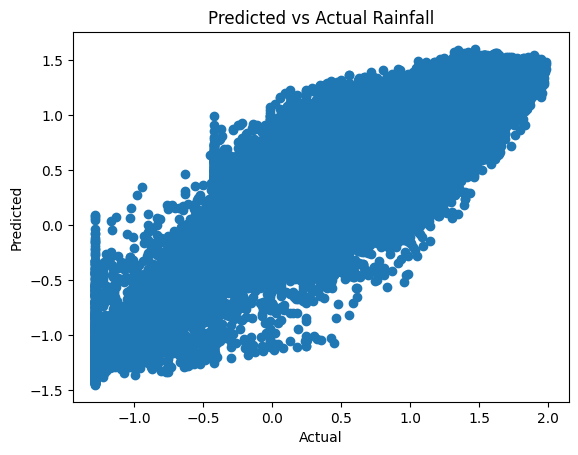

In [22]:
plt.figure()
plt.scatter(actuals, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Rainfall")
plt.show()

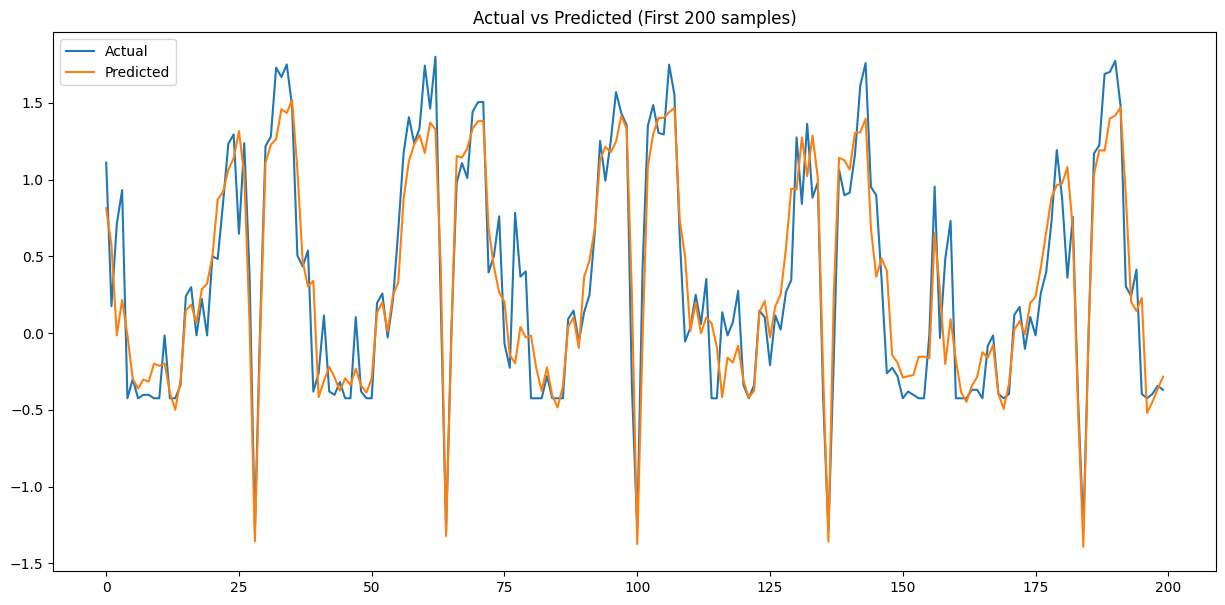

In [23]:
plt.figure(figsize=(15, 7))
plt.plot(actuals[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 200 samples)")
plt.show()

In [24]:
print(model)

iTransformer(
  (pcode_emb): Embedding(318, 32)
  (value_embedding): Linear(in_features=24, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=512, bias=True)
        (dropout): Dropout(p=0.10496930760427328, inplace=False)
        (linear2): Linear(in_features=512, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.10496930760427328, inplace=False)
        (dropout2): Dropout(p=0.10496930760427328, inplace=False)
      )
    )
  )
  (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=96, out_features=64,

In [27]:
results = pd.DataFrame({
    "actual": np.array(actuals).ravel(),
    "pred": np.array(preds).ravel()
})

results.to_csv("iTransformer_results.csv", index=False)

In [29]:
torch.save(model.state_dict(), "iTransformer_yeman_yr_model.pth")